# **초급 프로젝트 3팀 - Pill-터링**

#### 아래 코드들을 실행하여 기본 환경을 설정하고 데이터를 확인합니다.

> (중요) 구글 드라이브에 최소 7GB 이상은 확보되어 있어야 합니다!

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### `normalize_path`는?

`normalize_path`는 파일 경로에 포함된 **한글(유니코드) 처리 방식**을 통일하여, 경로를 찾지 못하는 에러를 방지하기 위한 함수입니다.

특히 **Google Colab**이나 **Mac, Windows** 사이에서 데이터를 주고받을 때 한글 폴더명이 깨져서 발생하는 `File Not Found` 에러를 잡는 데 필수적입니다.

<br>

##### 왜 사용하나요? (NFC vs NFD)

한글을 컴퓨터가 인식하는 방식은 크게 두 가지입니다.

* **NFC (Windows 스타일):** '강'을 '강'이라는 하나의 글자로 저장합니다.
* **NFD (Mac/Unix 스타일):** '강'을 'ㄱ', 'ㅏ', 'ㅇ'으로 쪼개서 저장합니다.

사람 눈에는 똑같이 "초급 프로젝트"라고 보이지만, 컴퓨터 입장에서는 글자 조합 방식이 다르면 **완전히 다른 경로**로 인식합니다. `normalize_path` 는 이를 **NFC(표준 방식)** 로 강제 통일해주는 역할을 합니다.

In [20]:
############################################################
# 0. 라이브러리 임포트 & 경로 설정
############################################################
import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

# 경로는 환경에 맞게 수정
# train_images, test_images
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/") # 압축을 풀 폴더

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train_images")
TEST_IMG_DIR  = os.path.join(extract_path, "test_images")

# merged_annotation json 경로
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############################################################
# 1. 병합된 JSON 파일을 읽어서 DataFrame으로 만들기
############################################################

def build_df_from_merged_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 1) 이미지 정보 매핑 (id -> file_name)
    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        file_name = id_to_fname.get(img_id_coco)
        
        if file_name is None: continue
        
        img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

# 실행
df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR)
print(f"✅ 학습 데이터 로드 완료: {len(df)} 개의 객체 탐지됨")

✅ 학습 데이터 로드 완료: 4526 개의 객체 탐지됨


In [3]:
############################################################
# 2. category_id 매핑 (겉으로는 안 바꾸고, 모델 내부에서만 사용)
############################################################

# 원본 category_id 집합
unique_cats = sorted(df["category_id"].unique())
print("고유 category_id 개수:", len(unique_cats))

# 내부용: 모델에 넣을 label (1 ~ num_classes-1), 0은 background
orig2model = {cid: i + 1 for i, cid in enumerate(unique_cats)}   # 원본 → 모델용
model2orig = {v: k for k, v in orig2model.items()}               # 모델용 → 원본

num_classes = len(unique_cats) + 1  # background 포함
print("num_classes (background 포함):", num_classes)

고유 category_id 개수: 73
num_classes (background 포함): 74


In [7]:
############################################################
# 3. Dataset 정의
############################################################

class OralDrugDataset(Dataset):
    """
    Faster R-CNN용 Dataset
    - __getitem__은 (image, target) 반환
    - image: [C,H,W] float tensor
    - target: dict(boxes, labels, image_id, ...)
    """
    def __init__(self, df, orig2model, transforms=None):
        self.df = df.reset_index(drop=True)
        self.orig2model = orig2model
        self.transforms = transforms

        # 이미지 단위로 그룹을 만들기 위해 고유 image_id 리스트를 유지
        self.image_ids = self.df["image_id"].unique().tolist()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        # 1) image_id 선택
        image_id = self.image_ids[idx]

        # 2) 해당 image_id에 해당하는 모든 row (여러 객체) 가져오기
        df_img = self.df[self.df["image_id"] == image_id]

        # 3) 이미지 로드
        img_path = df_img["image_path"].iloc[0]
        image = Image.open(img_path).convert("RGB")

        # 4) bbox / labels 구성
        boxes = []
        labels = []

        for _, row in df_img.iterrows():
            x = row["bbox_x"]
            y = row["bbox_y"]
            w = row["bbox_w"]
            h = row["bbox_h"]

            # [x1, y1, x2, y2] 형식으로 변환
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h
            boxes.append([x1, y1, x2, y2])

            # 원본 category_id → 모델용 label로 변환
            orig_cat = int(row["category_id"])
            model_cat = self.orig2model[orig_cat]
            labels.append(model_cat)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            # image_id는 loss에는 크게 영향 없음, 그냥 인덱스 정도로 넣어도 무방
            "image_id": torch.tensor([idx]),
        }

        if self.transforms is not None:
            image = self.transforms(image)

        return image, target




In [24]:
train_transforms = v2.Compose([ # 필요하다면 여기서 RandomHorizontalFlip 등 augmentation 추가
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    #v2.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

In [ ]:
############################################################
# 4. Transform, Dataset, DataLoader 구성
############################################################

dataset = OralDrugDataset(df, orig2model=orig2model, transforms=train_transforms)

# 간단히 train/val split (예: 90% train, 10% val)
indices = torch.randperm(len(dataset)).tolist()
split = int(0.9 * len(indices))
train_indices = indices[:split]
val_indices   = indices[split:]

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset   = torch.utils.data.Subset(dataset, val_indices)

def collate_fn(batch):
    # detection 모델용 collate_fn: 리스트의 튜플을 튜플의 리스트로
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,              # GPU 메모리에 맞게 조정
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
)

print("train steps:", len(train_loader), "val steps:", len(val_loader))

In [5]:
# 데이터프레임 찍어보기 (상위 5개)
print(df.head())

                                          image_path  \
0  /content/drive/MyDrive/data/초급_프로젝트/dataset/tr...   
1  /content/drive/MyDrive/data/초급_프로젝트/dataset/tr...   
2  /content/drive/MyDrive/data/초급_프로젝트/dataset/tr...   
3  /content/drive/MyDrive/data/초급_프로젝트/dataset/tr...   
4  /content/drive/MyDrive/data/초급_프로젝트/dataset/tr...   

                                           image_id  category_id  bbox_x  \
0  K-001900-016551-024850-027926_0_2_0_2_90_000_200         1899   158.0   
1  K-001900-016551-024850-027926_0_2_0_2_70_000_200         1899   631.0   
2  K-001900-016551-024850-027926_0_2_0_2_75_000_200         1899   143.0   
3  K-001900-016551-024850-027926_0_2_0_2_70_000_200        27925   146.0   
4  K-001900-016551-024850-027926_0_2_0_2_70_000_200        16550    29.0   

   bbox_y  bbox_w  bbox_h  
0   251.0   202.0   127.0  
1   893.0   210.0   133.0  
2   242.0   200.0   128.0  
3   143.0   257.0   456.0  
4   762.0   412.0   419.0  


In [10]:
with open(TRAIN_JSON_PATH, 'r') as f:
    train_data = json.load(f)

- 한 이미지 당 알약 수  

In [18]:
ann_counts = {}
for ann in train_data["annotations"]:
    img_id = ann["image_id"]
    ann_counts[img_id] = ann_counts.get(img_id, 0) + 1

# annotation 없는 이미지도 포함
for img in train_data["images"]:
    if img["id"] not in ann_counts:
        ann_counts[img["id"]] = 0

count_series = pd.Series(ann_counts.values())


print("=== 이미지당 알약 수 통계 ===")
print(count_series.describe())
print(f"\n0개 (annotation 없음): {(count_series == 0).sum()}장")
print(f"1개 : {(count_series == 1).sum()}장")
print(f"2개 : {(count_series == 2).sum()}장")
print(f"3개 : {(count_series == 3).sum()}장")
print(f"4개 : {(count_series == 4).sum()}장")
print(f"5개 이상 : {(count_series >= 5).sum()}장")

=== 이미지당 알약 수 통계 ===
count    1489.000000
mean        3.039624
std         0.837889
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         4.000000
dtype: float64

0개 (annotation 없음): 0장
1개 : 64장
2개 : 302장
3개 : 634장
4개 : 489장
5개 이상 : 0장


- 알약 카테고리 수

In [19]:
cat_counts = pd.Series([ann["category_id"] for ann in train_data["annotations"]]).value_counts().sort_index()
print("=== category당 annotation 수 ===")
print(cat_counts)
print(f"\n최대: {cat_counts.max()}개  |  최소: {cat_counts.min()}개")
print(f"평균: {cat_counts.mean():.1f}개")

bins   = [0, 100, 200, 300, 400, float('inf')]
labels = ['1~100', '101~200', '201~300', '301~400', '400+']

bin_counts = pd.cut(cat_counts, bins=bins, labels=labels).value_counts().sort_index()

print("=== annotation 당 카테고리 수 ===")
for label, count in bin_counts.items():
    print(f"{label:10s} : {count} cat")

=== category당 annotation 수 ===
1899     180
2482     172
3350     240
3482     514
3543      99
        ... 
35205    113
36636    108
38161     27
41767     23
44198     30
Name: count, Length: 73, dtype: int64

최대: 514개  |  최소: 7개
평균: 62.0개
=== annotation 당 카테고리 수 ===
1~100      : 62 cat
101~200    : 9 cat
201~300    : 1 cat
301~400    : 0 cat
400+       : 1 cat


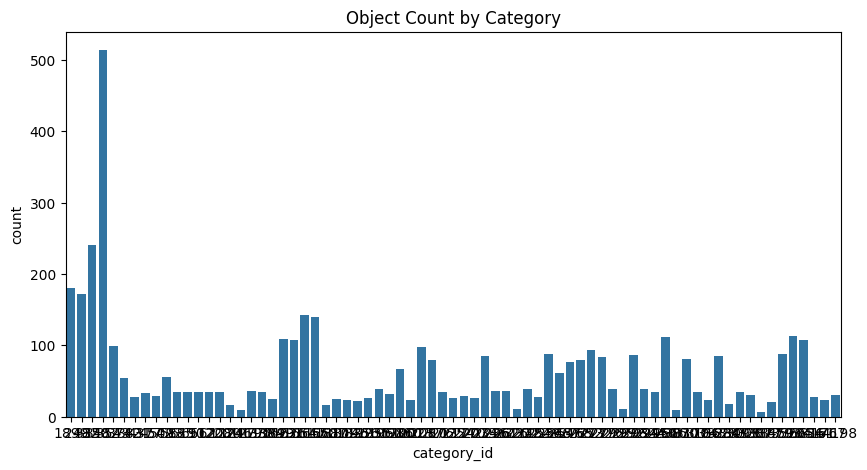

이미지당 평균 객체 수: 3.04


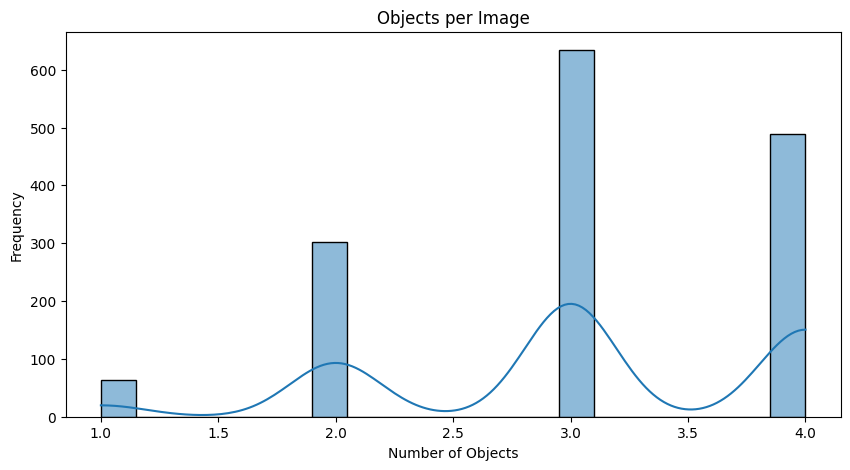

In [6]:
# 데이터 확인 (시각화)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 클래스별 데이터 개수 확인 (불균형 정제용)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='category_id')
plt.title("Object Count by Category")
plt.show()

# 2. 이미지당 객체 수 확인
objects_per_img = df.groupby('image_id').size()
print(f"이미지당 평균 객체 수: {objects_per_img.mean():.2f}")
plt.figure(figsize=(10, 5))
sns.histplot(objects_per_img, bins=20, kde=True)
plt.title("Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()

### Object Count by Category (카테고리별 불균형 확인)

> 분석: 어떤 카테고리(예: K-004)는 데이터가 500장 이상으로 넘쳐나는데, 다른 것들은 50장도 채 안 되는 게 보입니다.

> 정제 전략: 데이터가 너무 적은 카테고리는 모델이 학습하기 어려울 것 같습니다. 증강 및 AI-hub를 이용해 **"데이터 부족한 알약 위주로 추가 수집 팔요!"** (test dataset으로 쓰인 5000개짜리 제외)

- 제안1> Handle Outlier (400+ -> 300)

In [28]:
high_cats = cat_counts[cat_counts > 300].index.tolist()
TARGET_MAX = 300

df_balanced = []
for cat_id in df["category_id"].unique():
    df_cat = df[df["category_id"] == cat_id]
    if len(df_cat) > TARGET_MAX:
        df_cat = df_cat.sample(TARGET_MAX, random_state=42)
    df_balanced.append(df_cat)

df_balanced = pd.concat(df_balanced).reset_index(drop=True)
print(f"orignal_df : {len(df)}")
print(f"df_balanced : {len(df_balanced)}")

orignal_df : 4526
df_balanced : 4312


- 제안 2> Weighted random sampler

In [30]:
dataset = OralDrugDataset(df_balanced, orig2model=orig2model, transforms=train_transforms)

indices = torch.randperm(len(dataset)).tolist()
split   = int(0.9 * len(indices))
train_indices = indices[:split]
val_indices   = indices[split:]

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset   = torch.utils.data.Subset(dataset, val_indices)

In [31]:
from torch.utils.data import WeightedRandomSampler

total = cat_counts.sum()
cat_weight = {cat_id: total / count for cat_id, count in cat_counts.items()}

sample_weights = []
for img_id in dataset.image_ids:
    df_img = df_balanced[df_balanced["image_id"] == img_id]
    weight = max(cat_weight.get(int(row["category_id"]), 1.0)
        for _, row in df_img.iterrows())
    sample_weights.append(weight)

In [ ]:
train_weights = [sample_weights[i] for i in train_indices]

sampler = WeightedRandomSampler(
    weights     = train_weights,
    num_samples = len(train_weights),
    replacement = True)

train_loader = DataLoader(
    train_dataset,
    batch_size = 2,
    sampler = sampler, # not shuffle
    collate_fn = collate_fn)

val_loader = DataLoader(
    val_dataset,
    batch_size = 2,
    shuffle    = False,
    collate_fn = collate_fn)

print("train steps:", len(train_loader), "val steps  :", len(val_loader))

train steps: 669 val steps  : 75


### Objects per Image (이미지당 객체 수 분포)

> 분석: 평균 3.04개이고, 대부분의 이미지에 알약이 2~4개 정도 담겨 있음.

> 정제 전략: 만약 알약이 1개만 있는 이미지가 너무 많다면, 전처리 과정에서 이미지를 회전시키거나 합성해서 객체 수를 늘리는 파이프라인(Augmentation)을 구축해야 할 필요가 있음.

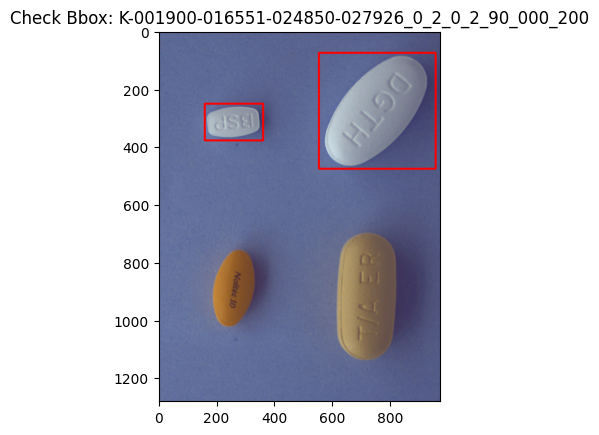

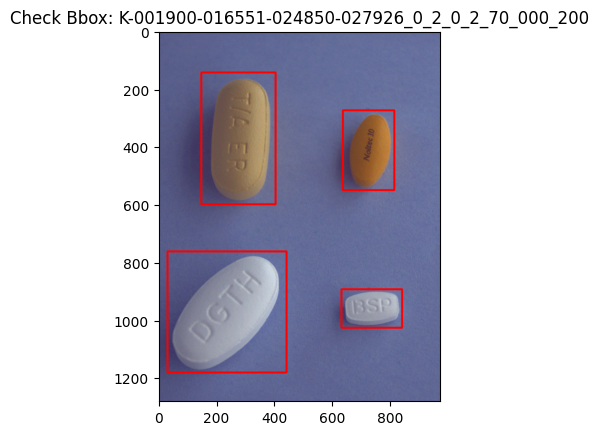

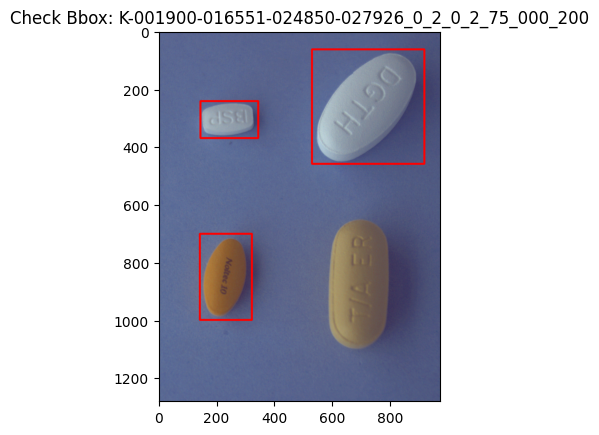

In [7]:
# 데이터 정제를 위한 시각화

import cv2
import matplotlib.pyplot as plt

def visualize_sample(df, n=3):
    sample_ids = df['image_id'].unique()[:n]
    for img_id in sample_ids:
        img_df = df[df['image_id'] == img_id]
        img = cv2.imread(img_df['image_path'].iloc[0])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        for _, row in img_df.iterrows():
            x, y, w, h = int(row['bbox_x']), int(row['bbox_y']), int(row['bbox_w']), int(row['bbox_h'])
            cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 5) # 빨간색 박스
            
        plt.imshow(img)
        plt.title(f"Check Bbox: {img_id}")
        plt.show()

visualize_sample(df)

### Check Bbox (바운딩 박스 검수)

> 분석: 알약 위에 빨간 박스가 아주 정확한 위치에 그려져 있는걸로 보임 (전체적으로 라벨링 품질은 좋아 보임).

In [9]:
# annotation id와 train data가 1:1 대응이 잘 되는지 확인

def check_data_alignment(df, img_dir):
    actual_files = set(os.listdir(img_dir))
    df_files = set(df['image_path'].apply(lambda x: os.path.basename(x)))
    
    # 이미지 파일은 있는데 JSON에 없는 경우 (Missing Label)
    missing_labels = actual_files - df_files
    # JSON에는 있는데 실제 파일은 없는 경우 (Missing Image)
    missing_images = df_files - actual_files
    
    print(f"✅ 교집합 검사 완료!")
    print(f"👉 라벨 없는 이미지: {len(missing_labels)}개")
    print(f"👉 이미지 없는 라벨: {len(missing_images)}개")

check_data_alignment(df, TRAIN_IMG_DIR)

✅ 교집합 검사 완료!
👉 라벨 없는 이미지: 0개
👉 이미지 없는 라벨: 0개


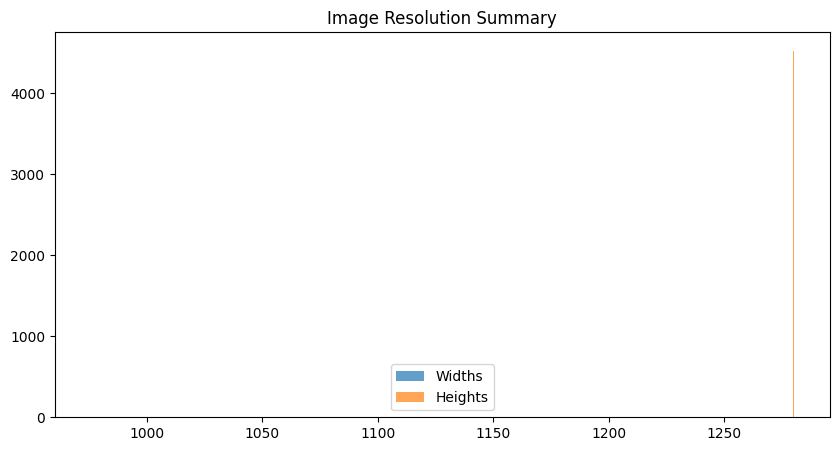

✅ 정제 완료: 0개 깨진 파일 제거됨. 남은 객체: 4526


In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# 🛠️ 데이터 정제 파이프라인 함수
def clean_and_summarize_dataset(df):
    clean_df = df.copy()
    resolutions = []
    
    # 1. 원본 PNG 사수 & 이미지 품질 검수 (Image Quality Check)
    indices_to_drop = []
    for idx, row in df.iterrows():
        try:
            # 해상도 통계요약 (Resolution Summary)
            with Image.open(row['image_path']) as img:
                resolutions.append(img.size) # (width, height)
        except Exception as e:
            # 깨진 파일 자동삭제 (corrupted file removal)
            print(f"🚨 깨진 이미지 발견 및 삭제 예정: {row['image_path']}")
            indices_to_drop.append(idx)
            
    clean_df.drop(indices_to_drop, inplace=True)
    clean_df.reset_index(drop=True, inplace=True)
    
    # 2. 해상도 통계 시각화
    plt.figure(figsize=(10, 5))
    widths, heights = zip(*resolutions)
    plt.hist(widths, bins=20, alpha=0.7, label='Widths')
    plt.hist(heights, bins=20, alpha=0.7, label='Heights')
    plt.title("Image Resolution Summary")
    plt.legend()
    plt.show()
    
    print(f"✅ 정제 완료: {len(indices_to_drop)}개 깨진 파일 제거됨. 남은 객체: {len(clean_df)}")
    return clean_df

# 루미의 데이터프레임에 파이프라인 적용!
df_cleaned = clean_and_summarize_dataset(df)

### 해상도 완벽 통일 (Consistency):

> 그래프에 막대기가 딱 한 줄(1280 부근)만 뾰족하게 솟아있는 것은 모든 이미지의 가로(Width)와 세로(Height)가 **똑같은 크기(예: 1280x1280)**로 깔끔하게 정리가 잘 된것을 볼 수 있음.  
모델 학습할 때 리사이즈 비율을 고민할 필요가 없어서 성능이 아주 안정적으로 나올 거라 추측해볼 수 있음.

### 깨진 파일 0개 (Reliability):

> 하단에 "0개 깨진 파일 제거됨"은 수집한 모든 데이터가 읽기 가능한 상태라는 뜻.

### 데이터 무결성 확인:

> 남은 객체 수가 4,526개로 찍혔는데, 나중에 학습 돌릴 때 이 숫자가 줄어들지 않는지 체크 필요

## 결론

> 데이터의 라벨링이 잘 되었는지, 해상도는 괜찮은지 등의 여부는 원래 확인 후 정제 및 분석하여 최종 모델링에 들어가야하지만, 이 프로젝트에서는 이미 정제된 데이터셋으로 받았으므로 저희는 정제를 어떻게 하는지에 대해 학습하고 간단히 시각화로 확인하는 정도로만 진행하였습니다.  
실제 모델링에서는 라벨링 오류, 해상도 이상치, 클래스 불균형 등 다양한 문제를 정제 과정에서 발견하고 해결하는 것이 중요합니다.  
증강을 진행 후 먼저 모델을 한 번 돌려서 결과값을 도출한 후에 모델에 대한 데이터가 부족하다고 판단되어 데이터의 수집이 더 필요한 경우, AI-hub의 경구약 이미지 인식 데이터셋에서 추가로 TEST 데이터셋 제외한 나머지 데이터를 수집하여 모델링에 활용할 예정입니다.

In [12]:
# Yolo 전용 Dataset 클래스

import os

# 1. YOLO 라벨을 저장할 경로 설정 (이미지 폴더와 같은 레벨의 labels 폴더)
# extract_path를 기준으로 'labels' 폴더를 지정!
YOLO_LABEL_DIR = os.path.join(extract_path, "labels") 

def save_yolo_labels_v2(df, output_path):
    os.makedirs(output_path, exist_ok=True)
    
    # 해상도 검사했을 때 1280이었으므로 변수로 지정해서 계산
    IMG_W, IMG_H = 1280, 1280
    
    for img_id, group in df.groupby('image_id'):
        # 파일명 기반으로 .txt 파일 생성
        label_file = os.path.join(output_path, f"{img_id}.txt")
        
        with open(label_file, 'w', encoding='utf-8') as f:
            for _, row in group.iterrows():
                # YOLO 클래스 (0부터 시작하도록 보정 - 만약 1부터 시작한다면 row['category_id'] - 1)
                cls = int(row['category_id'])
                
                # 좌표 변환 (Center X, Center Y, Width, Height) / Image Size
                x_center = (row['bbox_x'] + row['bbox_w'] / 2) / IMG_W
                y_center = (row['bbox_y'] + row['bbox_h'] / 2) / IMG_H
                w = row['bbox_w'] / IMG_W
                h = row['bbox_h'] / IMG_H
                
                # YOLO 포맷으로 쓰기
                f.write(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# ✅ 실행
save_yolo_labels_v2(df, YOLO_LABEL_DIR)

print(f"✅ YOLO 라벨 생성 완료: {YOLO_LABEL_DIR}")
print(f"📁 생성된 라벨 수: {len(os.listdir(YOLO_LABEL_DIR))} 개")

✅ YOLO 라벨 생성 완료: /content/drive/MyDrive/data/초급_프로젝트/dataset/labels
📁 생성된 라벨 수: 1489 개


In [13]:
# 1. 원래 데이터프레임에 있던 유니크한 이미지 개수
original_image_count = df['image_id'].nunique()

# 2. 직접 생성한 YOLO 라벨 파일 개수
generated_label_count = len(os.listdir(YOLO_LABEL_DIR))

print(f"원본 이미지 수: {original_image_count}")
print(f"생성된 라벨 수: {generated_label_count}")

if original_image_count == generated_label_count:
    print("✅ 모든 이미지에 대한 라벨이 생성됨.")
else:
    print("⚠️ 개수가 맞지 않으므로 확인 필요.")

원본 이미지 수: 1489
생성된 라벨 수: 1489
✅ 모든 이미지에 대한 라벨이 생성됨.


> 선생님이 주신 베이스라인 코드는 Faster R-CNN 코드이므로 저희가 진행할 YOLO 버전에 맞게 Dataset 클래스를 새로 만들었습니다.  
데이터는 해상도 1280으로 고정되어 있어 이를 반영한 YOLO 최적화 변환 스크립트를 작성했습니다. 클래스 불균형 해소를 위해 추후 Weighted Sampling 로직 및 기타 증강도 아래에 넣었습니다.

In [10]:

############################################################
# 5. 모델 정의 (Faster R-CNN + ResNet50 FPN 전이학습)
############################################################

# 사전학습된 Faster R-CNN 모델 로드
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# 분류 head를 우리 데이터셋 클래스 개수에 맞게 교체
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(DEVICE)

# 옵티마이저 설정
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

# (선택) 러닝레이트 스케줄러
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


############################################################
# 6. 학습 루프
############################################################

num_epochs = 5  # 혹은 원하는 에폭 수
optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

for epoch in range(num_epochs):
    ##########################
    # 1) Train
    ##########################
    model.train()
    train_loss_sum = 0.0

    for images, targets in train_loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss_sum += losses.item()

    avg_train_loss = train_loss_sum / max(1, len(train_loader))

    ##########################
    # 2) Validation (loss만 측정)
    ##########################
    model.train()  # ★ 여기 중요: eval()이 아니라 train() 상태에서 호출해야 loss 나옴
    val_loss_sum = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss_sum += losses.item()

    avg_val_loss = val_loss_sum / max(1, len(val_loader))

    print(f"[Epoch {epoch+1}/{num_epochs}] "
          f"train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f}")

    # 스케줄러 한 스텝
    scheduler.step()

# 학습된 모델 저장 (원하면)
torch.save(model.state_dict(), "fasterrcnn_oral_drug.pth")
print("모델 저장 완료")



Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 241MB/s] 


[Epoch 1/5] train_loss: 0.6681 | val_loss: 0.3017
[Epoch 2/5] train_loss: 0.3909 | val_loss: 0.2302
[Epoch 3/5] train_loss: 0.3283 | val_loss: 0.2843
[Epoch 4/5] train_loss: 0.2472 | val_loss: 0.1231
[Epoch 5/5] train_loss: 0.2009 | val_loss: 0.1064
모델 저장 완료


In [ ]:

############################################################
# 7. test_images에 대해 예측 → submission.csv 생성
############################################################

# test 이미지 파일 목록 가져오기
test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")]
test_files = sorted(test_files)

model.eval()

rows = []
annotation_id = 1      # submission용 annotation_id 시작
score_threshold = 0.3  # 너무 낮은 점수는 제거 (필요에 따라 조정)

with torch.no_grad():
    for f in test_files:
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")

        # image_id = 파일명에서 확장자 제거한 문자열 그대로 사용
        image_id = os.path.splitext(f)[0]

        img_tensor = T.ToTensor()(image).to(DEVICE)
        outputs = model([img_tensor])[0]

        keep = outputs["scores"].cpu() >= score_threshold
        boxes  = outputs["boxes"].cpu()[keep]
        labels = outputs["labels"].cpu()[keep]
        scores = outputs["scores"].cpu()[keep]

        for box, lab, sc in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box.tolist()
            w = x2 - x1
            h = y2 - y1

            orig_cat = model2orig[int(lab.item())]

            rows.append({
                "annotation_id": annotation_id,
                "image_id": image_id,  # 문자열 그대로 사용
                "category_id": orig_cat,
                "bbox_x": x1,
                "bbox_y": y1,
                "bbox_w": w,
                "bbox_h": h,
                "score": float(sc.item()),
            })

            annotation_id += 1

# DataFrame으로 만들고 저장
df_sub = pd.DataFrame(rows, columns=[
    "image_id", "category_id",
    "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
])
# 이미지 ID별로 점수 높은 순 정렬 후 상위 4개 추출
df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
df_sub = df_sub.groupby("image_id").head(4)

# 3) 최종 annotation_id 부여 (1부터 순차적으로)
df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

# 4) CSV 저장
output_path = "final_submission.csv"
df_sub.to_csv(os.path.join(extract_path, output_path), index=False)

print(f"✅ 생성 완료: {output_path}")
print(f"📊 총 예측 객체 수: {len(df_sub)}")
print(df_sub.head())

✅ 생성 완료: final_submission.csv
📊 총 예측 객체 수: 3257
   annotation_id image_id  category_id      bbox_x      bbox_y      bbox_w  \
0              1        1        16550  556.429443   71.300697  399.382629   
1              2        1         1899  159.593399  249.843170  201.259079   
2              3        1        27925  597.204590  675.783875  257.736023   
3              4        1        24849  169.360229  743.308411  183.695557   
4              5       10        16547  104.827522  809.451233  237.359764   

       bbox_h     score  
0  403.272270  0.981536  
1  127.119537  0.980955  
2  475.985046  0.963797  
3  289.701111  0.941548  
4  232.094421  0.986859  


In [12]:
############################################################
# 8. 모델 성능 평가 (mAP 측정)
############################################################

import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# 1. df_sub(Pandas)를 COCO 평가용 리스트로 변환
eval_results = []
for _, row in df_sub.iterrows():
    eval_results.append({
        "image_id": int(row["image_id"]),
        "category_id": int(row["category_id"]),
        "bbox": [row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"]],
        "score": float(row["score"])
    })

# 2. 임시 JSON 파일로 저장
temp_json = "temp_eval.json"
with open(temp_json, "w") as f:
    json.dump(eval_results, f)

# 3. COCO 평가 실행
coco_gt = COCO(TEST_JSON_PATH)
coco_dt = coco_gt.loadRes(temp_json)

coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.29s).
Accumulating evaluation results...
DONE (t=0.48s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.374
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.397
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.395
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.374
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.898
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.898
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe